<a href="https://colab.research.google.com/github/RAGHAVA9999-gif/DeepLearning/blob/main/RNN_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import string
import random
import torch
import gc
import matplotlib.pyplot as plt
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# Data preprocessing

In [ ]:
train_df = pd.read_csv('/content/trainmerged.csv')
val_df = pd.read_csv('/content/valmerged.csv')
test_df = pd.read_csv('/content/testmerged.csv')

In [ ]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (17224, 3)
Validation Shape: (2193, 3)
Test Shape: (2157, 3)


In [ ]:
print("Train Samples:")
print(train_df.head())

Train Samples:
                                               Tweet          Target   Stance
0  "Policy Over Politics" & "People Over Profits"...  Bernie Sanders    FAVOR
1  "Bernie knows"? Bernie knows it's bullshit, bu...  Bernie Sanders    FAVOR
2  Well, a sad day for all my communist friends. ...  Bernie Sanders  AGAINST
3  Back in 1995, @SenSanders used his time to cal...  Bernie Sanders    FAVOR
4  Anyone else NOT comforted by promises to get t...  Bernie Sanders  AGAINST


In [ ]:
train_df.value_counts("Stance")

,count
Stance,
AGAINST,8877
FAVOR,8347


In [ ]:
print("Train")
print(train_df["Stance"].value_counts())

print("\nValidation")
print(val_df["Stance"].value_counts())

print("\nTest")
print(test_df["Stance"].value_counts())

Train
Stance
AGAINST    8877
FAVOR      8347
Name: count, dtype: int64

Validation
Stance
AGAINST    1141
FAVOR      1052
Name: count, dtype: int64

Test
Stance
AGAINST    1125
FAVOR      1032
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
train_df["Clean_Tweet"] = train_df["Tweet"].apply(clean_text)
val_df["Clean_Tweet"] = val_df["Tweet"].apply(clean_text)
test_df["Clean_Tweet"] = test_df["Tweet"].apply(clean_text)

In [ ]:
print(train_df["Clean_Tweet"].head(2))

0    policy over politics people over profits would...
1    bernie knows bernie knows its bullshit but he ...
Name: Clean_Tweet, dtype: object


In [ ]:
label_map = {
    "AGAINST":0,
    "FAVOR":1,
    "NONE":2
}

In [ ]:
train_df["label"] = train_df["Stance"].map(label_map)
val_df["label"] = val_df["Stance"].map(label_map)
test_df["label"] = test_df["Stance"].map(label_map)

In [ ]:
print(train_df["label"].value_counts())

label
0    8877
1    8347
Name: count, dtype: int64


In [ ]:
#Drop Nan values
train_df.dropna(subset=['label'], inplace=True)
val_df.dropna(subset=['label'], inplace=True)
test_df.dropna(subset=['label'], inplace=True)
#convert float into int
train_df['label'] = train_df['label'].astype(int)
val_df['label'] = val_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

In [ ]:
counter = Counter()
for sentence in train_df["Clean_Tweet"]:
    counter.update(sentence.split())
vocab = {
    "<PAD>":0,
    "<UNK>":1
}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)


In [ ]:
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 13212


In [ ]:
def text_to_sequence(text, vocab):
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

train_sequences = [text_to_sequence(text, vocab) for text in train_df["Clean_Tweet"]]
val_sequences = [text_to_sequence(text, vocab) for text in val_df["Clean_Tweet"]]
test_sequences = [text_to_sequence(text, vocab) for text in test_df["Clean_Tweet"]]

In [ ]:
print(train_sequences[:2])

[[2, 3, 4, 5, 3, 6, 7, 8, 9, 1, 10, 11, 12, 13], [13, 14, 13, 14, 15, 16, 17, 8, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 19, 34, 35, 36, 37, 38, 39, 40, 41, 8, 42, 43, 1, 1]]


In [ ]:
MAX_LEN = 64
def pad_sequences(sequences, max_len):
    padded = []
    for seq in sequences:
        if len(seq) < max_len:
            seq = seq + [0]*(max_len-len(seq))
        else:
            seq = seq[:max_len]
        padded.append(seq)
    return torch.tensor(padded)

In [ ]:
X_train = pad_sequences(train_sequences, MAX_LEN)
X_val = pad_sequences(val_sequences, MAX_LEN)
X_test = pad_sequences(test_sequences, MAX_LEN)

In [ ]:
print(X_train[0])
print(X_train[1])

tensor([ 2,  3,  4,  5,  3,  6,  7,  8,  9,  1, 10, 11, 12, 13,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0])
tensor([13, 14, 13, 14, 15, 16, 17,  8, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
        28, 29, 30, 31, 32, 33, 19, 34, 35, 36, 37, 38, 39, 40, 41,  8, 42, 43,
         1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [ ]:
y_train = torch.tensor(train_df["label"].values).long()
y_val = torch.tensor(val_df["label"].values).long()
y_test = torch.tensor(test_df["label"].values).long()

In [ ]:
print(y_train[0])
print(y_train[1])

tensor(1)
tensor(1)


# DataSet

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
train_dataset = StanceDataset(X_train, y_train)
val_dataset = StanceDataset(X_val, y_val)
test_dataset = StanceDataset(X_test, y_test)

In [ ]:
print(train_dataset[0])

(tensor([ 2,  3,  4,  5,  3,  6,  7,  8,  9,  1, 10, 11, 12, 13,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0]), tensor(1))


# DataLoader

In [ ]:
g = torch.Generator()
g.manual_seed(42)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,generator=g)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [ ]:
for inputs, labels in train_loader:
    print("Input Shape :", inputs.shape)
    print("Labels Shape:", labels.shape)
    print(inputs[:2])
    print(labels[:2])
    break

Input Shape : torch.Size([32, 64])
Labels Shape: torch.Size([32])
tensor([[  158,   155,     1,  8915,   158,    45,  9571,  9252,   253,     8,
           741,  3934,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0],
        [   25,   544,   554,     8,  7274,   222,   621,    25,   456,   176,
           202,     8,     7,   321,    79,    25,   456,   314,    89,   418,
          2783,   222,    19,  1134,   337,    10,   163,   621,  3295,   232,
             3,    45,   533,  2598,  1785,    25,    90, 12225,   132,    89,
             1,   232,    19,   183,    47,   155,    25,    26,     1,     0,
             0,     0,     

# Models

**Lstm**

In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=300,
                 hidden_dim=128,
                 output_dim=2,
                 num_layers=1,
                 dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim,
                                      padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])
        out = self.fc(hidden)
        return out

**Gru**

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=300,
                 hidden_dim=128,
                 output_dim=2,
                 num_layers=1,
                 dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1])
        out = self.fc(hidden)
        return out

**Mini Lstm**

In [ ]:
class MiniLSTMClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=128,
                 hidden_dim=64,
                 output_dim=2):
        super(MiniLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out

**Mini Gru**

In [ ]:
class MiniGRUClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=128,
                 hidden_dim=64,
                 output_dim=2):
        super(MiniGRUClassifier, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        out = self.fc(hidden[-1])
        return out

# Loss

In [ ]:
criterion = nn.CrossEntropyLoss()

# Train

In [ ]:

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    model_name="model",
    scheduler=None,
    save_dir="checkpoints"
):
    os.makedirs(save_dir, exist_ok=True)
    model = model.to(device)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    best_val_acc = 0.0
    for epoch in range(num_epochs):
       #train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
            leave=False
        )
        for inputs, labels in train_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_bar.set_postfix(
                loss=f"{train_loss/(train_bar.n+1):.4f}",
                acc=f"{100*train_correct/train_total:.2f}%"
            )
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Valid]",
            leave=False
        )
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_bar.set_postfix(
                    loss=f"{val_loss/(val_bar.n+1):.4f}",
                    acc=f"{100*val_correct/val_total:.2f}%"
                )
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = val_correct / val_total

        # Save history
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        # Scheduler
        if scheduler is not None:
            scheduler.step()

        # Save Best Model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(
                model.state_dict(),
                os.path.join(save_dir, f"{model_name}_best.pth")
            )


        # Save Checkpoint
        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        }

        torch.save(
            checkpoint,
            os.path.join(
                save_dir,
                f"{model_name}_checkpoint_epoch_{epoch+1}.pth"
            )
        )

        #Epoch
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} "
            f"Val Acc: {epoch_val_acc:.4f}"
        )
    return history

# Plotting

In [ ]:
def plot_loss(history, model_name="Model"):
    plt.figure(figsize=(8,5))
    plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(history, model_name="Model"):
    plt.figure(figsize=(8,5))
    plt.plot(history["train_acc"], label="Train Accuracy", linewidth=2)
    plt.plot(history["val_acc"], label="Validation Accuracy", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluation

In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
def evaluate_model(model, test_loader, device):
    model.eval()
    model.to(device)
    predictions = []
    true_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average="binary")
    recall = recall_score(true_labels, predictions, average="binary")
    f1 = f1_score(true_labels, predictions, average="binary")
    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

#ROC

In [ ]:
def get_roc_data(model, test_loader, device):
    model.eval()
    model.to(device)
    y_true = []
    y_score = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_score.extend(probabilities.cpu().numpy())
    return np.array(y_true), np.array(y_score)

# Initializing Lstm

In [ ]:
# LSTM
lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
history_lstm = train_model( lstm_model,train_loader,val_loader,criterion,optimizer,num_epochs=10,device=device,model_name="LSTM")


Epoch 1/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 0.6931 Train Acc: 0.5125 | Val Loss: 0.6923 Val Acc: 0.5203


Epoch 2/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 0.3135 Train Acc: 0.8852 | Val Loss: 0.8531 Val Acc: 0.6534


Epoch 10/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 0.2806 Train Acc: 0.9018 | Val Loss: 0.8661 Val Acc: 0.6589


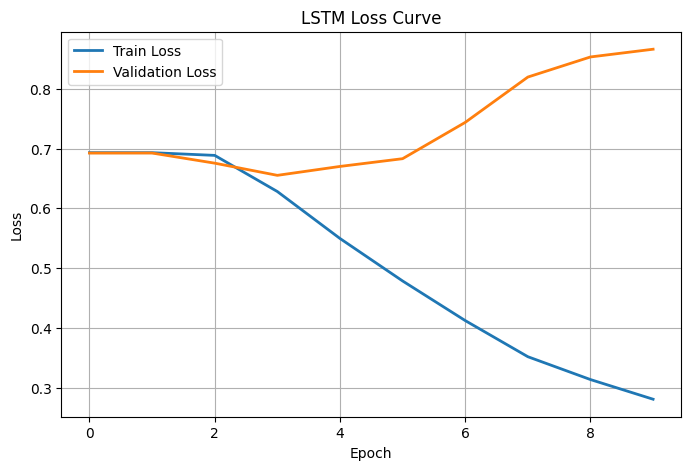

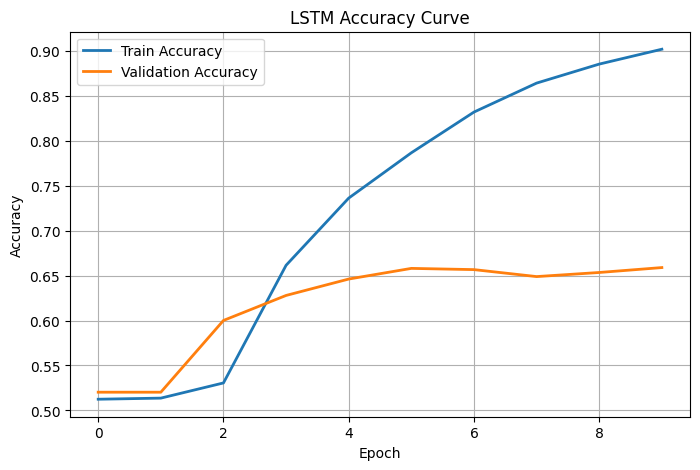

In [ ]:
plot_loss(history_lstm, "LSTM")
plot_accuracy(history_lstm, "LSTM")

In [ ]:
lstm_results = evaluate_model(lstm_model,test_loader,device)
lstm_y_true, lstm_y_score = get_roc_data(lstm_model,test_loader,device)


Accuracy : 0.6597
Precision: 0.6364
Recall   : 0.6734
F1-Score : 0.6544


# GPU memory reset

In [ ]:
if 'lstm_model' in globals():
    del lstm_model
if 'optimizer' in globals():
    del optimizer
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")

17.25 MB
56.0 MB


# Initializing Gru

In [ ]:
gru_model = GRUClassifier(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
history_gru = train_model( gru_model,train_loader,val_loader,criterion, optimizer,num_epochs=10,device=device,model_name="GRU")


Epoch 1/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 0.6932 Train Acc: 0.5121 | Val Loss: 0.6922 Val Acc: 0.5203


Epoch 2/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 0.0361 Train Acc: 0.9884 | Val Loss: 1.5740 Val Acc: 0.6726


Epoch 10/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 0.0300 Train Acc: 0.9908 | Val Loss: 1.6244 Val Acc: 0.6694


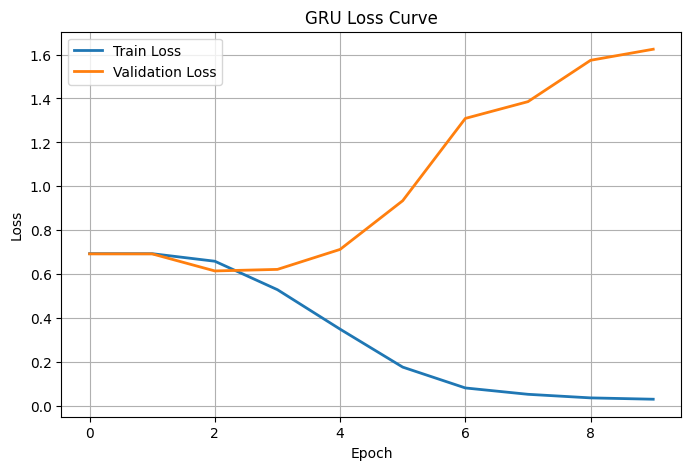

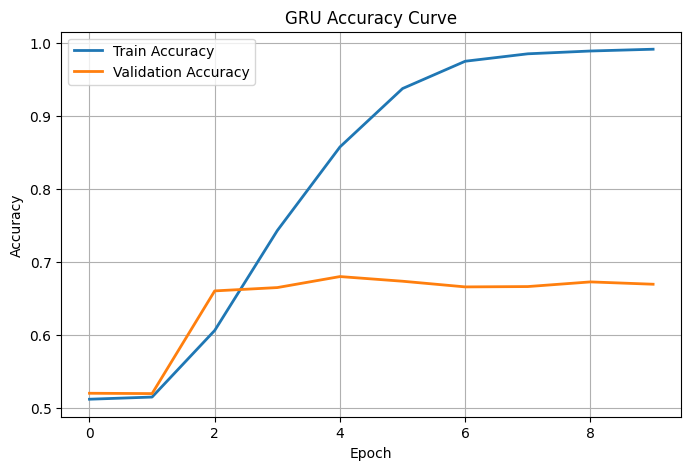

In [ ]:
plot_loss(history_gru, "GRU")
plot_accuracy(history_gru, "GRU")

In [ ]:
gru_results = evaluate_model(gru_model,test_loader,device)
gru_y_true, gru_y_score = get_roc_data(gru_model,test_loader,device)


Accuracy : 0.6528
Precision: 0.6372
Recall   : 0.6366
F1-Score : 0.6369


# GPU memory reset

In [ ]:
if 'gru_model' in globals():
    del gru_model
if 'optimizer' in globals():
    del optimizer

torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")

17.25 MB
56.0 MB


# Initializing MiniLstm

In [ ]:
mini_lstm_model = MiniLSTMClassifier(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(mini_lstm_model.parameters(), lr=1e-3)
history_mini_lstm = train_model( mini_lstm_model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device=device, model_name="MiniLSTM")


Epoch 1/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 0.6930 Train Acc: 0.5106 | Val Loss: 0.6925 Val Acc: 0.5203


Epoch 2/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 0.3524 Train Acc: 0.8648 | Val Loss: 0.7340 Val Acc: 0.6548


Epoch 10/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 0.2737 Train Acc: 0.9054 | Val Loss: 0.8189 Val Acc: 0.6594


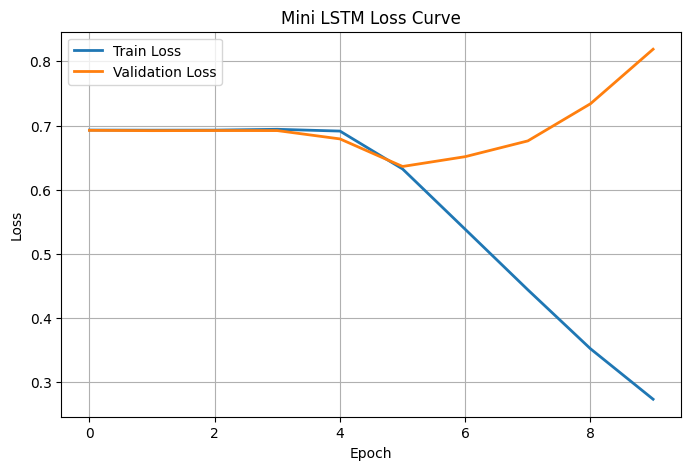

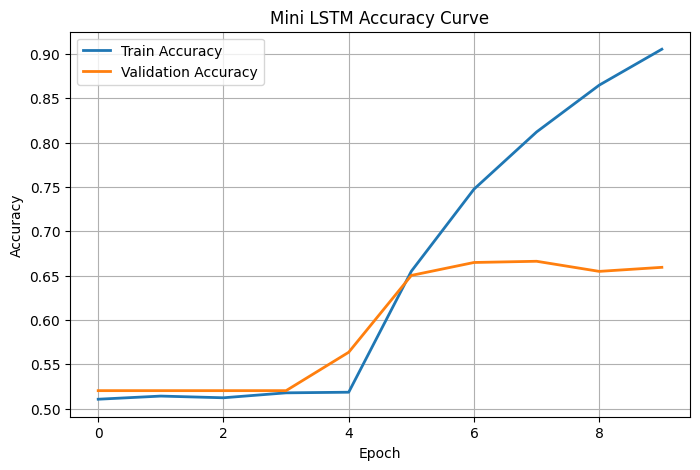

In [ ]:
plot_loss(history_mini_lstm, "Mini LSTM")
plot_accuracy(history_mini_lstm, "Mini LSTM")

In [ ]:
mini_lstm_results = evaluate_model(mini_lstm_model,test_loader,device)
mini_lstm_y_true, mini_lstm_y_score = get_roc_data(mini_lstm_model,test_loader,device)


Accuracy : 0.6704
Precision: 0.6728
Recall   : 0.6056
F1-Score : 0.6374


# GPU memory reset

In [ ]:
if 'mini_lstm_model' in globals():
    del mini_lstm_model
if 'optimizer' in globals():
    del optimizer
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")

17.25 MB
56.0 MB


##Initializing miniGru

In [ ]:
mini_gru_model = MiniGRUClassifier(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(mini_gru_model.parameters(), lr=1e-3)
history_mini_gru = train_model(mini_gru_model,train_loader,val_loader,criterion,optimizer,num_epochs=10,device=device,model_name="MiniGRU")


Epoch 1/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 0.6932 Train Acc: 0.5100 | Val Loss: 0.6925 Val Acc: 0.5203


Epoch 2/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 0.0675 Train Acc: 0.9794 | Val Loss: 1.4313 Val Acc: 0.6585


Epoch 10/10 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 0.0484 Train Acc: 0.9858 | Val Loss: 1.5259 Val Acc: 0.6635


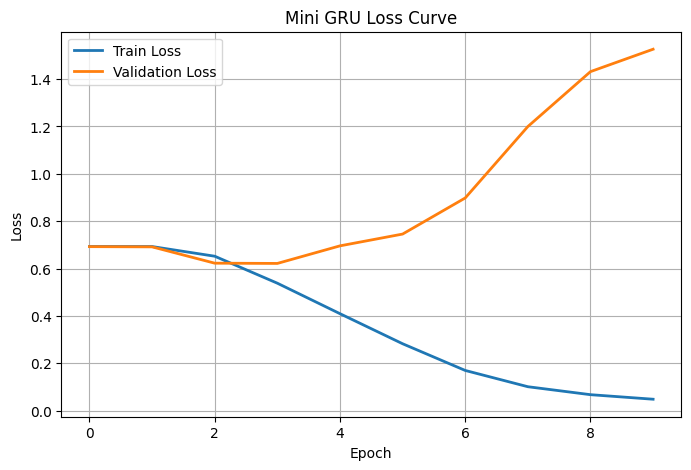

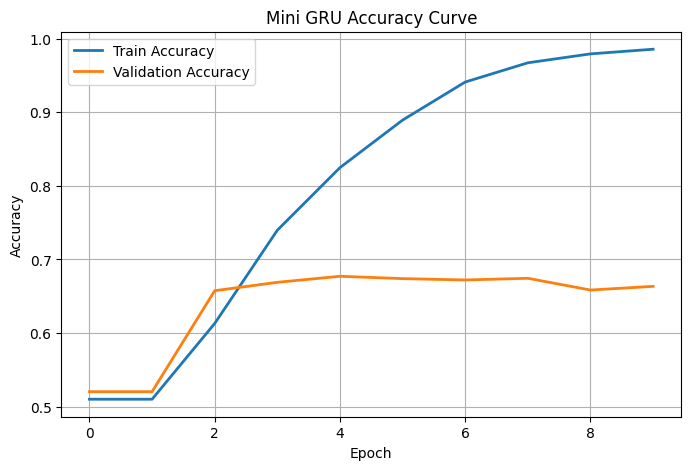

In [ ]:
plot_loss(history_mini_gru, "Mini GRU")
plot_accuracy(history_mini_gru, "Mini GRU")

In [ ]:
mini_gru_results = evaluate_model( mini_gru_model, test_loader, device)
mini_gru_y_true, mini_gru_y_score = get_roc_data(mini_gru_model,test_loader,device)


Accuracy : 0.6648
Precision: 0.6396
Recall   : 0.6860
F1-Score : 0.6620


# GPU memory reset

In [ ]:
if 'mini_gru_model' in globals():
    del mini_gru_model
if 'optimizer' in globals():
    del optimizer
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")

17.25 MB
56.0 MB


# Roc

In [ ]:
def plot_multiclass_roc(y_true, y_score, model_name):
    y_score_positive_class = y_score[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_score_positive_class )
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

lstm_fpr, lstm_tpr, lstm_auc = plot_multiclass_roc(lstm_y_true,lstm_y_score,"LSTM")
gru_fpr, gru_tpr, gru_auc = plot_multiclass_roc(gru_y_true,gru_y_score,"GRU")
mini_lstm_fpr, mini_lstm_tpr, mini_lstm_auc = plot_multiclass_roc(mini_lstm_y_true,mini_lstm_y_score,"Mini LSTM")
mini_gru_fpr, mini_gru_tpr, mini_gru_auc = plot_multiclass_roc(mini_gru_y_true,mini_gru_y_score,"Mini GRU")

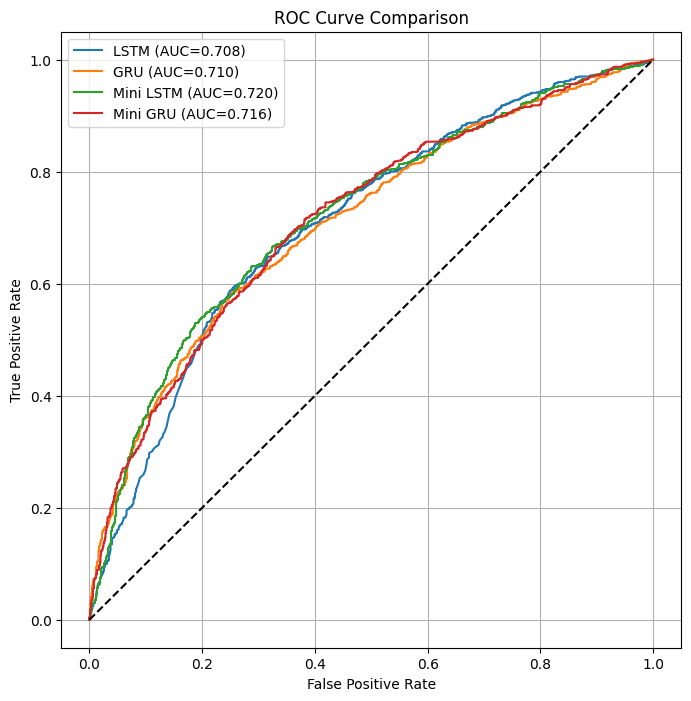

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(lstm_fpr,lstm_tpr,label=f"LSTM (AUC={lstm_auc:.3f})")
plt.plot(gru_fpr,gru_tpr,label=f"GRU (AUC={gru_auc:.3f})")
plt.plot(mini_lstm_fpr,mini_lstm_tpr,label=f"Mini LSTM (AUC={mini_lstm_auc:.3f})")
plt.plot(mini_gru_fpr,mini_gru_tpr,label=f"Mini GRU (AUC={mini_gru_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()